# Copenhagen's Cycling Pulse: How Weather Shapes Bicycle Traffic

**Dataset**: [Copenhagen bicycle counter data (2014)](https://www.opendata.dk/city-of-copenhagen/faste-cykeltaellinger) + [DMI hourly weather observations (2014)](https://opendataapi.dmi.dk/v2/metObs/bulk/2014/)

**Pipeline**: Data Cleaning → Merge → EDA → Interactive Narrative Visualization  

---

## 0 — Setup & Configuration

All imports, output directories, and a column-mapping dictionary you can adjust if your raw files differ.

In [1]:
import os, zipfile, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from pyproj import Transformer
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from branca.colormap import LinearColormap

# Style settings
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.alpha": 0.3,
})
sns.set_palette("colorblind")

# Output directories
os.makedirs("./docs/images", exist_ok=True)
os.makedirs("./docs/visualizations", exist_ok=True)

# Column-mapping
COLUMN_MAP = {
    # Excel bike data
    "sensor_id": "Vej_Id", # unique sensor key
    "road_name": "Vejnavn",
    "direction": "Spor", # direction / 'T' for total
    "utm_x":     "X_UTM32",
    "utm_y":     "Y_UTM32",
    "date_col":  "Dato", # date string dd.mm.yyyy
    # Weather JSON
    "w_station":  "stationId",
    "w_param":    "parameterId",
    "w_value":    "value",
    "w_observed": "observed",
}

# DMI stations
CPH_STATIONS = {"06180", "06186", "06181", "06187"}
# | StationId | Name                | Notes                            |
# | --------- | ------------------- | -------------------------------- |
# | 06180     | Københavns Lufthavn | Copenhagen Airport (Kastrup)     |
# | 06187     | Københavns Toldbod  | Central harbour / city area      |
# | 06186     | Landbohøjskolen     | Inner Copenhagen (Frederiksberg) |
# | 06181     | Jægersborg          | North of city (Gentofte/Lyngby)  |

# Weather parameters we need
WEATHER_PARAMS = {"temp_dry", "precip_past1h", "wind_speed", "humidity"}

---
## Step 1 — Data Cleaning & Merging

### 1.1 Load & reshape bicycle counter data

The Excel file has a 10-row metadata header.  
Each row = one sensor × one day, with 24 hourly count columns (`kl.00-01` … `kl.23-24`).  
Sensors come in triplets: `-` (direction A), `+` (direction B), `T` (total). We keep only **`T`** rows to avoid double-counting.

In [2]:
HOUR_COLS_RAW = [
    "kl_00_01", "kl_01_02", "kl_02_03", "kl_03_04", "kl_04_05", "kl_05_06",
    "kl_06_07", "kl_07_08", "kl_08_09", "kl_09_10", "kl_10_11", "kl_11_12",
    "kl_12_13", "kl_13_14", "kl_14_15", "kl_15_16", "kl_16_17", "kl_17_18",
    "kl_18_19", "kl_19_20", "kl_20_21", "kl_21_22", "kl_22_23", "kl_23_24",
]
ALL_COLS = [
    "Vej_Id", "Vejnavn", "Spor", "X_UTM32", "Y_UTM32", "Dato",
] + HOUR_COLS_RAW

df_bike_raw = pd.read_excel(
    "./data/cykeltaellinger-2014.xlsx",
    header=None,
    skiprows=11, # data starts at row 11
    names=ALL_COLS,
)

print(f"Raw bike rows : {len(df_bike_raw):,}")
df_bike_raw.head(3)

Raw bike rows : 7,509


,Vej_Id,Vejnavn,Spor,X_UTM32,Y_UTM32,Dato,kl_00_01,kl_01_02,kl_02_03,kl_03_04,...,kl_14_15,kl_15_16,kl_16_17,kl_17_18,kl_18_19,kl_19_20,kl_20_21,kl_21_22,kl_22_23,kl_23_24
0,101 1011492-0 1/ 1 -,Ellebjergvej,NaN,720887,6172775,01.01.2014,5,3.0,2.0,6,...,3,5,13,1,0,3,3,2,0,2.0
1,101 1011492-0 1/ 1 -,Ellebjergvej,NaN,720887,6172775,02.01.2014,1,1.0,1.0,0,...,13,10,17,14,3,4,9,3,1,1.0
2,101 1011492-0 1/ 1 -,Ellebjergvej,NaN,720887,6172775,03.01.2014,0,0.0,0.0,3,...,30,8,11,4,5,6,2,6,0,2.0


In [3]:
# Keep only the 'T' (total) rows
# The Vej_Id ends with '-', '+', or 'T' indicating direction vs total
df_bike = df_bike_raw[df_bike_raw["Vej_Id"].str.strip().str.endswith("T")].copy()

# Remove possible leading/trailing whitespace
df_bike["Vej_Id"] = df_bike["Vej_Id"].str.strip()
df_bike["Vejnavn"] = df_bike["Vejnavn"].str.strip()

# Parse dates  (format: dd.mm.yyyy)
df_bike["date"] = pd.to_datetime(df_bike["Dato"], format="%d.%m.%Y", errors="coerce")
df_bike = df_bike.dropna(subset=["date"])

print(f"Total-only rows: {len(df_bike):,}  ({df_bike['Vej_Id'].nunique()} sensors)")
print(f"Date range : {df_bike['date'].min().date()} -> {df_bike['date'].max().date()}")
df_bike[["Vej_Id", "Vejnavn", "X_UTM32", "Y_UTM32"]].drop_duplicates()

Total-only rows: 2,503  (9 sensors)
Date range : 2014-01-01 -> 2014-12-31


,Vej_Id,Vejnavn,X_UTM32,Y_UTM32
598,101 1011492-0 1/ 1 T,Ellebjergvej,720887,6172775
1613,101 1011908-0 0/ 66 T,Fredensbro,724290,6177606
2687,101 1011964-0 0/ 200 T,Frederikssundsvej,722023,6178546
3559,101 1012890-0 6/ 560 T,Hareskovvej,719487,6180473
4106,101 1013520-0 0/ 562 T,Kalvebod Brygge,724562,6174877
4275,101 1015968-0 1/ 60 T,Roskildevej,718731,6175142
5003,101 1017592-0 0/ 635 T,Torvegade,726066,6175240
6077,101 1018308-0 1/ 516 T,Vigerslev Allé,721273,6174037
7151,101 1018636-0 0/ 180 T,Åboulevard,723530,6176573


In [4]:
# ── Melt into long format: one row per sensor × date × hour ─────────────────
id_vars = ["Vej_Id", "Vejnavn", "X_UTM32", "Y_UTM32", "date"]
df_long = df_bike.melt(
    id_vars=id_vars,
    value_vars=HOUR_COLS_RAW,
    var_name="hour_label",
    value_name="count",
)

# Extract hour integer from the label (e.g. 'kl_07_08' → 7)
df_long["hour"] = df_long["hour_label"].str.extract(r"kl_(\d{2})_").astype(int)

# Build a full datetime
df_long["datetime"] = df_long["date"] + pd.to_timedelta(df_long["hour"], unit="h")
df_long["datetime"] = df_long["datetime"].dt.tz_localize("Europe/Copenhagen", nonexistent="shift_forward", ambiguous="NaT")

# Ensure count is numeric
df_long["count"] = pd.to_numeric(df_long["count"], errors="coerce").fillna(0).astype(int)

# Drop helper columns
df_long = df_long.drop(columns=["hour_label", "date", "hour"])

print(f"Long-format rows: {len(df_long):,}")
df_long.head()

Long-format rows: 60,072


,Vej_Id,Vejnavn,X_UTM32,Y_UTM32,count,datetime
0,101 1011492-0 1/ 1 T,Ellebjergvej,720887,6172775,17,2014-01-01 00:00:00+01:00
1,101 1011492-0 1/ 1 T,Ellebjergvej,720887,6172775,3,2014-01-02 00:00:00+01:00
2,101 1011492-0 1/ 1 T,Ellebjergvej,720887,6172775,6,2014-01-03 00:00:00+01:00
3,101 1011492-0 1/ 1 T,Ellebjergvej,720887,6172775,6,2014-01-04 00:00:00+01:00
4,101 1011492-0 1/ 1 T,Ellebjergvej,720887,6172775,5,2014-01-05 00:00:00+01:00


In [5]:
# Convert UTM32 → WGS84 (lat / lon)
transformer = Transformer.from_crs("EPSG:25832", "EPSG:4326", always_xy=True)

sensor_coords = (
    df_long[["Vej_Id", "Vejnavn", "X_UTM32", "Y_UTM32"]]
    .drop_duplicates(subset=["Vej_Id"])
    .copy()
)

lons, lats = transformer.transform(
    sensor_coords["X_UTM32"].values,
    sensor_coords["Y_UTM32"].values,
)
sensor_coords["lon"] = lons
sensor_coords["lat"] = lats

# Merge lat/lon back into the long dataframe
df_long = df_long.merge(
    sensor_coords[["Vej_Id", "lat", "lon"]],
    on="Vej_Id",
    how="left",
)

print("Sensor locations (WGS84):")
sensor_coords.head()

Sensor locations (WGS84):


,Vej_Id,Vejnavn,X_UTM32,Y_UTM32,lon,lat
0,101 1011492-0 1/ 1 T,Ellebjergvej,720887,6172775,12.510872,55.650522
299,101 1011908-0 0/ 66 T,Fredensbro,724290,6177606,12.568790,55.692289
657,101 1011964-0 0/ 200 T,Frederikssundsvej,722023,6178546,12.533558,55.701761
1015,101 1012890-0 6/ 560 T,Hareskovvej,719487,6180473,12.494825,55.720197
1272,101 1013520-0 0/ 562 T,Kalvebod Brygge,724562,6174877,12.570876,55.667689


### 1.2 Load weather data from ZIP (Copenhagen stations only)

The ZIP contains 365 daily `.txt` files, each with ~170 K line-delimited GeoJSON features for **all** Danish stations.  
We stream through the ZIP without extracting and keep only records from Copenhagen-area stations for the four parameters we need.

In [6]:
WEATHER_CACHE = "./data/copenhagen_weather_2014.csv"

if os.path.exists(WEATHER_CACHE):
    # Fast reload from cache
    print("Loading weather from cache …")
    df_weather = pd.read_csv(WEATHER_CACHE, parse_dates=["observed"])
else:
    # Parse from the ZIP 
    print("Parsing weather ZIP — this may take a few minutes …")
    records = []
    with zipfile.ZipFile("./data/2014.zip", "r") as z:
        for fname in sorted(z.namelist()):
            if not fname.endswith(".txt"):
                continue
            with z.open(fname) as f:
                for line in f:
                    rec = json.loads(line)
                    props = rec["properties"]
                    if (
                        props["stationId"] in CPH_STATIONS
                        and props["parameterId"] in WEATHER_PARAMS
                    ):
                        records.append({
                            "stationId":   props["stationId"],
                            "parameterId": props["parameterId"],
                            "value":       props["value"],
                            "observed":    props["observed"],
                        })
            # progress indicator
            print(f"  {fname} → {len(records):,} records so far", end="\r")

    df_weather = pd.DataFrame(records)
    df_weather["observed"] = pd.to_datetime(df_weather["observed"], utc=True)
    df_weather.to_csv(WEATHER_CACHE, index=False)
    print(f"\nDone. {len(df_weather):,} weather records cached to {WEATHER_CACHE}")

print(f"Weather rows: {len(df_weather):,}")
df_weather.head()

Loading weather from cache …
Weather rows: 427,227


,stationId,parameterId,value,observed
0,6181,temp_dry,3.5,2014-01-01 23:50:00+00:00
1,6180,humidity,90.0,2014-01-01 23:50:00+00:00
2,6186,temp_dry,3.9,2014-01-01 23:50:00+00:00
3,6181,humidity,93.0,2014-01-01 23:50:00+00:00
4,6181,wind_speed,4.3,2014-01-01 23:50:00+00:00


In [7]:
# Pivot: one row per (station, hour), columns = weather parameters ────────
df_weather["observed"] = pd.to_datetime(df_weather["observed"], utc=True)

# Round to the nearest hour (some obs are at :50, :00, etc.)
df_weather["hour"] = df_weather["observed"].dt.round("h")

# For each (stationId, hour, parameterId) keep the latest observation
df_weather = (
    df_weather
    .sort_values("observed")
    .drop_duplicates(subset=["stationId", "hour", "parameterId"], keep="last")
)

df_wpivot = df_weather.pivot_table(
    index=["stationId", "hour"],
    columns="parameterId",
    values="value",
    aggfunc="mean",
).reset_index()

# Average across Copenhagen stations to get one row per hour
df_w_hourly = (
    df_wpivot
    .drop(columns=["stationId"])
    .groupby("hour")
    .mean()
    .reset_index()
)

# Localize to Copenhagen
df_w_hourly["datetime"] = df_w_hourly["hour"].dt.tz_convert("Europe/Copenhagen")
df_w_hourly = df_w_hourly.drop(columns=["hour"])

print(f"Hourly weather rows: {len(df_w_hourly):,}")
print(f"Columns: {list(df_w_hourly.columns)}")
df_w_hourly.head()

Hourly weather rows: 8,761
Columns: ['humidity', 'precip_past1h', 'temp_dry', 'wind_speed', 'datetime']


parameterId,humidity,precip_past1h,temp_dry,wind_speed,datetime
0,85.333333,0.0,3.633333,5.10,2014-01-01 01:00:00+01:00
1,87.666667,0.0,3.566667,5.15,2014-01-01 02:00:00+01:00
2,89.000000,0.0,3.533333,5.60,2014-01-01 03:00:00+01:00
3,89.333333,0.0,3.700000,6.40,2014-01-01 04:00:00+01:00
4,89.000000,0.0,3.833333,6.40,2014-01-01 05:00:00+01:00


### 1.3 Merge bike counts with weather

In [8]:
# Left-join: keep all bike observations
df_merged = df_long.merge(df_w_hourly, on="datetime", how="left")

# Handle missing weather data
df_merged["temp_dry"] = df_merged["temp_dry"].ffill() # forward-fill temperature
df_merged["precip_past1h"] = df_merged["precip_past1h"].fillna(0) # assume no rain if missing
df_merged["wind_speed"] = df_merged["wind_speed"].ffill()
df_merged["humidity"] = df_merged["humidity"].ffill()

# Data integrity check
print(f"Merged rows : {len(df_merged):,}")
print(f"Date range : {df_merged['datetime'].min()} → {df_merged['datetime'].max()}")
print(f"\nMissing (%) per column:")
print((df_merged.isnull().mean()*100).round(2).to_string())
df_merged.head()

# Save the merged dataset for future analysis
MERGED_CACHE = "./data/bike_weather_merged.csv"
df_merged.to_csv(MERGED_CACHE, index=False)
print(f"\nMerged dataset saved to {MERGED_CACHE}")

Merged rows : 60,072
Date range : 2014-01-01 00:00:00+01:00 → 2014-12-31 23:00:00+01:00

Missing (%) per column:
Vej_Id           0.00
Vejnavn          0.00
X_UTM32          0.00
Y_UTM32          0.00
count            0.00
datetime         0.01
lat              0.00
lon              0.00
humidity         0.00
precip_past1h    0.00
temp_dry         0.00
wind_speed       0.00

Merged dataset saved to ./data/bike_weather_merged.csv


In [9]:
# Handy aggregations

# City-wide hourly total
df_city_hourly = (
    df_merged
    .groupby("datetime")
    .agg(total_count=("count", "sum"),
         temp_dry=("temp_dry", "mean"),
         precip_past1h=("precip_past1h", "mean"),
         wind_speed=("wind_speed", "mean"),
         humidity=("humidity", "mean"))
    .reset_index()
)

# City-wide daily total
df_city_daily = (
    df_city_hourly
    .assign(date=lambda x: x["datetime"].dt.date)
    .groupby("date")
    .agg(total_count=("total_count", "sum"),
         temp_dry=("temp_dry", "mean"),
         precip_daily=("precip_past1h", "sum"),
         wind_speed=("wind_speed", "mean"),
         humidity=("humidity", "mean"))
    .reset_index()
)
df_city_daily["date"] = pd.to_datetime(df_city_daily["date"])

# Per-sensor daily total
df_sensor_daily = (
    df_merged
    .assign(date=lambda x: x["datetime"].dt.date)
    .groupby(["Vej_Id", "Vejnavn", "lat", "lon", "date"])
    .agg(daily_count=("count", "sum"),
         precip_daily=("precip_past1h", "sum"),
         precip_max_h=("precip_past1h", "max"))
    .reset_index()
)
df_sensor_daily["date"] = pd.to_datetime(df_sensor_daily["date"])

print(f"City hourly : {len(df_city_hourly):,} rows")
print(f"City daily : {len(df_city_daily):,} rows")
print(f"Sensor daily : {len(df_sensor_daily):,} rows")

City hourly : 8,590 rows
City daily : 358 rows
Sensor daily : 2,503 rows


---
## Step 2 — Exploratory Data Analysis

### 2.1 Correlation matrix

Saved -> docs/images/correlation_matrix.png


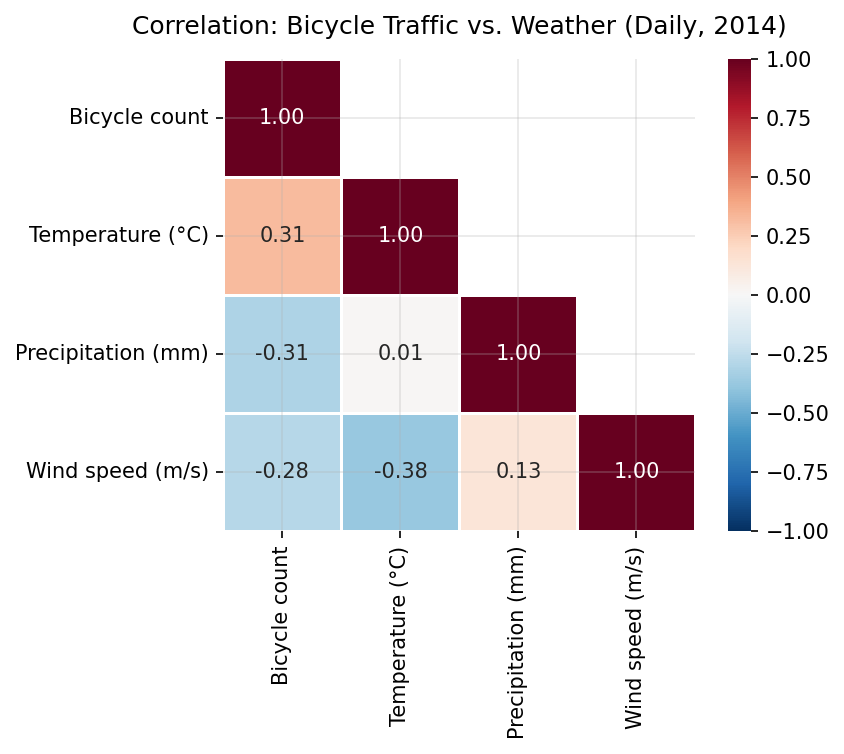

In [10]:
corr_cols = ["total_count", "temp_dry", "precip_daily", "wind_speed"]
corr_labels = ["Bicycle count", "Temperature (°C)", "Precipitation (mm)", "Wind speed (m/s)"]

corr = df_city_daily[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=corr_labels,
    yticklabels=corr_labels,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation: Bicycle Traffic vs. Weather (Daily, 2014)", fontsize=12, pad=12)
fig.tight_layout()
fig.savefig("./docs/images/correlation_matrix.png", dpi=300, bbox_inches="tight")
print("Saved -> docs/images/correlation_matrix.png")
plt.show()

### 2.2 Time-series: 7-day rolling average + daily precipitation

Saved -> docs/images/rolling_avg_precip.png


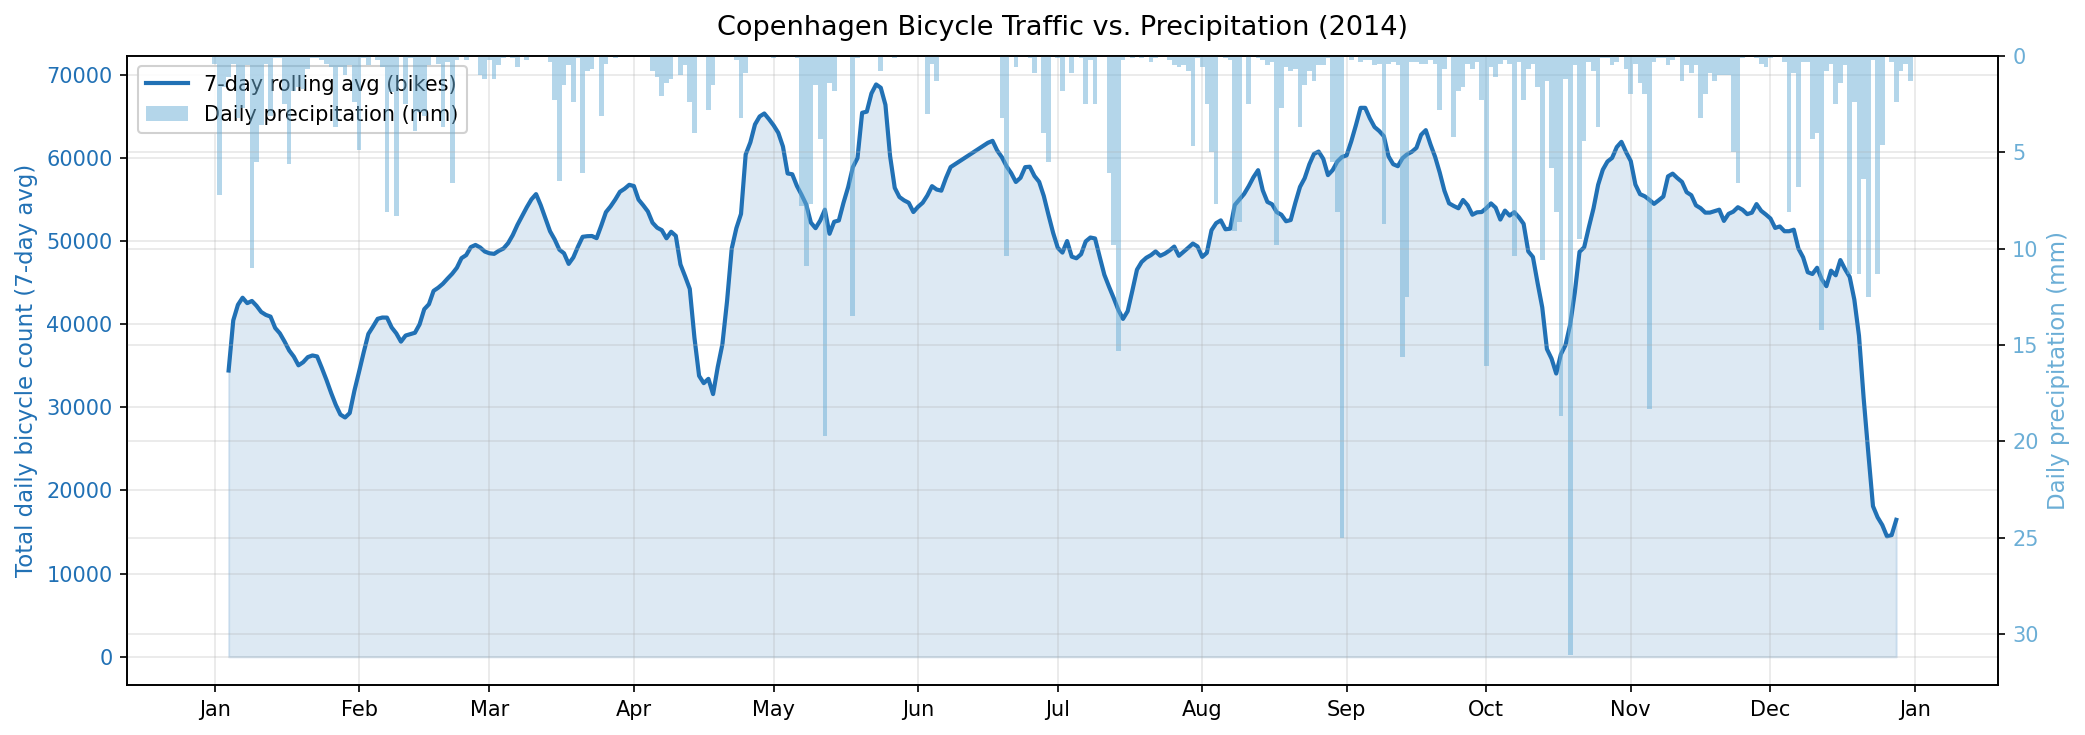

In [11]:
df_city_daily["rolling_7d"] = df_city_daily["total_count"].rolling(7, center=True).mean()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Left axis — bicycle count rolling average
color_bike = "#2171b5"
ax1.plot(df_city_daily["date"], df_city_daily["rolling_7d"],
         color=color_bike, linewidth=2, label="7-day rolling avg (bikes)")
ax1.fill_between(df_city_daily["date"], df_city_daily["rolling_7d"],
                 alpha=0.15, color=color_bike)
ax1.set_ylabel("Total daily bicycle count (7-day avg)", color=color_bike, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_bike)
ax1.set_xlabel("")

# Right axis — precipitation
ax2 = ax1.twinx()
color_rain = "#6baed6"
ax2.bar(df_city_daily["date"], df_city_daily["precip_daily"],
        color=color_rain, alpha=0.5, width=1, label="Daily precipitation (mm)")
ax2.set_ylabel("Daily precipitation (mm)", color=color_rain, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_rain)
ax2.invert_yaxis()  # rain bars hang from top → intuitive "falling rain"

# Formatting
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.set_title("Copenhagen Bicycle Traffic vs. Precipitation (2014)", fontsize=13, pad=10)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)

fig.tight_layout()
fig.savefig("./docs/images/rolling_avg_precip.png", dpi=300, bbox_inches="tight")
print("Saved -> docs/images/rolling_avg_precip.png")
plt.show()

#### 2.2b Time-series: Raw daily count + daily precipitation

Saved -> docs/images/daily_count_precip.png


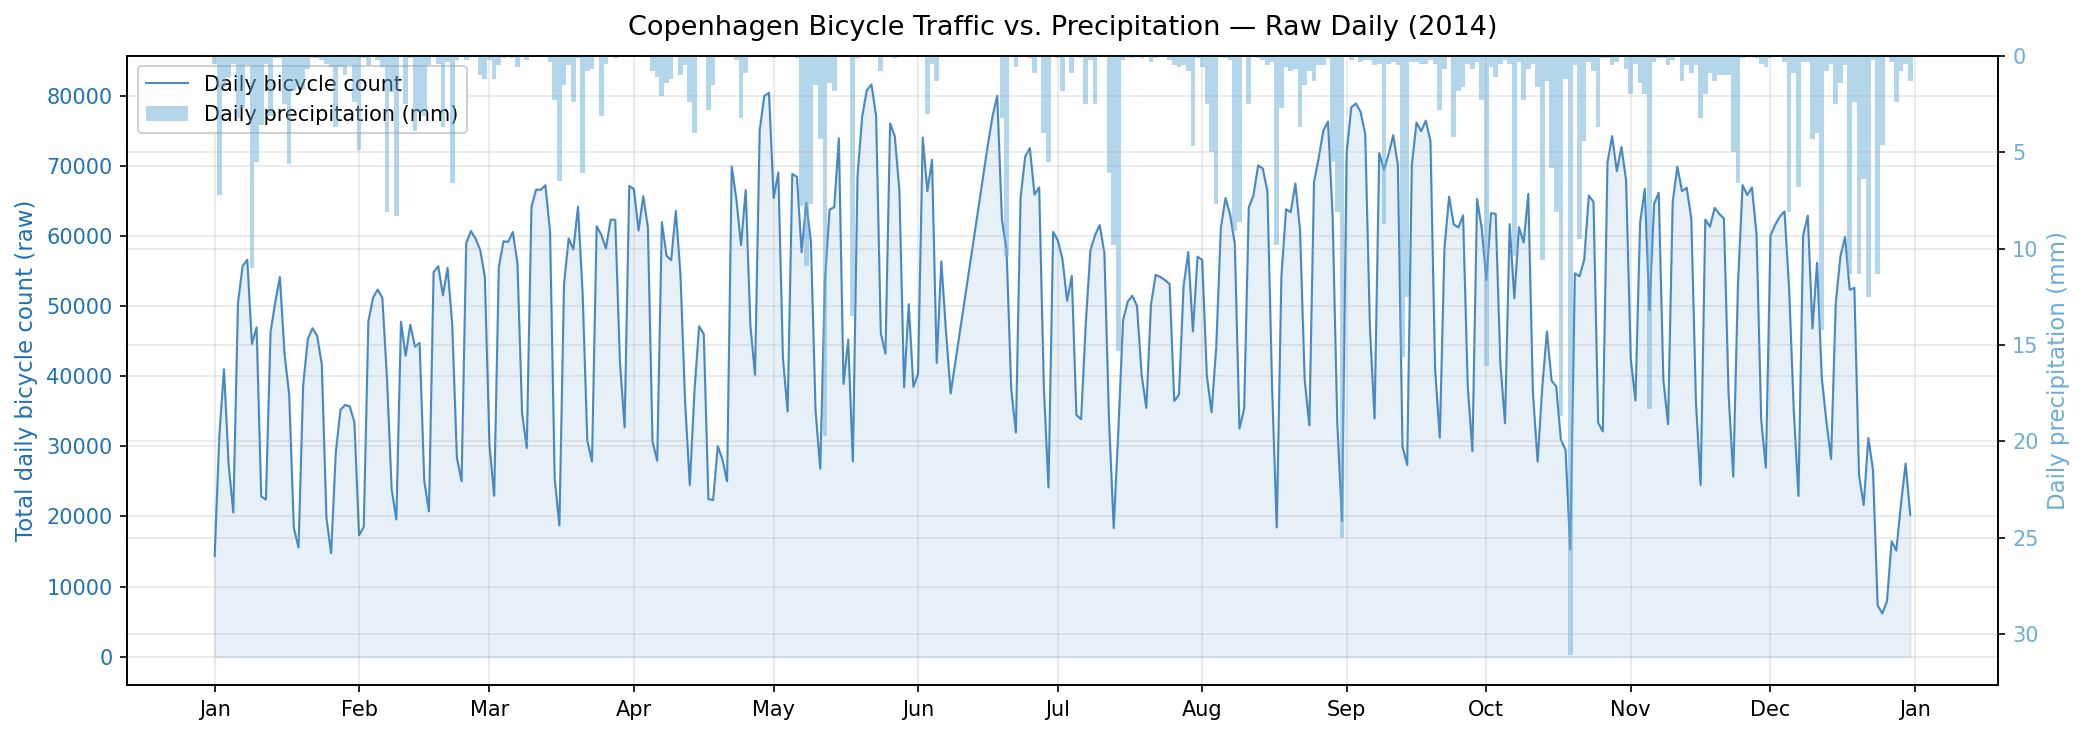

In [12]:
fig, ax1 = plt.subplots(figsize=(14, 5))

# Left axis — raw daily bicycle count
color_bike = "#2171b5"
ax1.plot(df_city_daily["date"], df_city_daily["total_count"],
         color=color_bike, linewidth=1, alpha=0.8, label="Daily bicycle count")
ax1.fill_between(df_city_daily["date"], df_city_daily["total_count"],
                 alpha=0.1, color=color_bike)
ax1.set_ylabel("Total daily bicycle count (raw)", color=color_bike, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_bike)
ax1.set_xlabel("")

# Right axis — precipitation
ax2 = ax1.twinx()
color_rain = "#6baed6"
ax2.bar(df_city_daily["date"], df_city_daily["precip_daily"],
        color=color_rain, alpha=0.5, width=1, label="Daily precipitation (mm)")
ax2.set_ylabel("Daily precipitation (mm)", color=color_rain, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_rain)
ax2.invert_yaxis()  # rain bars hang from top → intuitive "falling rain"

# Formatting
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.set_title("Copenhagen Bicycle Traffic vs. Precipitation — Raw Daily (2014)", fontsize=13, pad=10)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)

fig.tight_layout()
fig.savefig("./docs/images/daily_count_precip.png", dpi=300, bbox_inches="tight")
print("Saved -> docs/images/daily_count_precip.png")
plt.show()

### 2.3 Scatter plot: Temperature vs. daily bicycle count

Saved -> docs/images/temp_vs_bikes_scatter.png


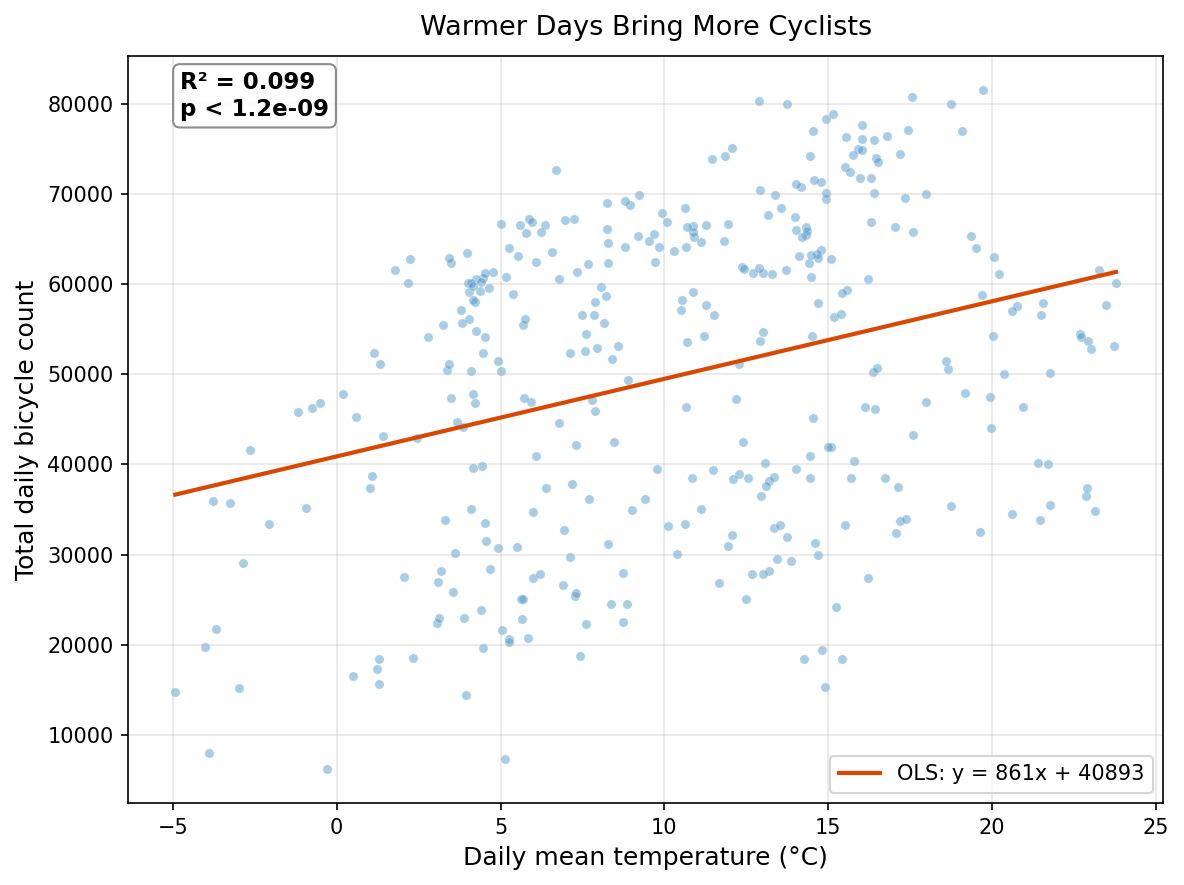

In [13]:
x = df_city_daily["temp_dry"].values
y = df_city_daily["total_count"].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.45, s=20, color="#4292c6", edgecolors="white", linewidth=0.3)

# Regression line
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="#d94801", linewidth=2,
        label=f"OLS: y = {slope:.0f}x + {intercept:.0f}")

ax.annotate(
    f"R² = {r_value**2:.3f}\np < {p_value:.1e}",
    xy=(0.05, 0.92), xycoords="axes fraction",
    fontsize=11, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
)

ax.set_xlabel("Daily mean temperature (°C)", fontsize=12)
ax.set_ylabel("Total daily bicycle count", fontsize=12)
ax.set_title("Warmer Days Bring More Cyclists", fontsize=13, pad=10)
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig("./docs/images/temp_vs_bikes_scatter.png", dpi=300, bbox_inches="tight")
print(f"Saved -> docs/images/temp_vs_bikes_scatter.png")
plt.show()

### 2.4 Rain Impact Score & Wind Resistance

Rain Impact Score
  Mean hourly bikes (dry)  : 2,161
  Mean hourly bikes (rainy): 1,732
  Drop during rain         : 19.9%
Saved -> docs/images/wind_resistance.png


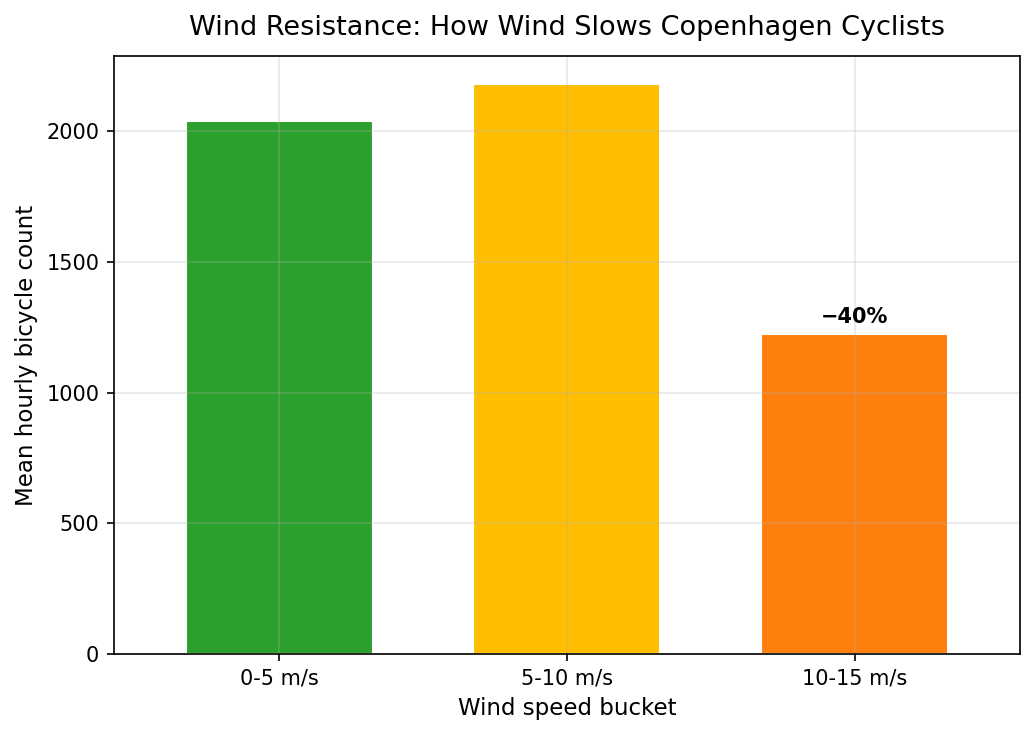

In [14]:
# Rain Impact Score (city-wide, hourly)
dry_mask  = df_city_hourly["precip_past1h"] == 0
rain_mask = df_city_hourly["precip_past1h"] > 0

mean_dry  = df_city_hourly.loc[dry_mask, "total_count"].mean()
mean_rain = df_city_hourly.loc[rain_mask, "total_count"].mean()
rain_impact_pct = (1 - mean_rain / mean_dry) * 100

print(f"Rain Impact Score")
print(f"  Mean hourly bikes (dry)  : {mean_dry:,.0f}")
print(f"  Mean hourly bikes (rainy): {mean_rain:,.0f}")
print(f"  Drop during rain         : {rain_impact_pct:.1f}%")

# Wind Resistance (city-wide, hourly)
wind_bins = [0, 5, 10, 15, 100]
wind_labels = ["0-5 m/s", "5-10 m/s", "10-15 m/s", "15+ m/s"]
df_city_hourly["wind_bucket"] = pd.cut(
    df_city_hourly["wind_speed"], bins=wind_bins, labels=wind_labels, right=False
)
wind_stats = df_city_hourly.groupby("wind_bucket", observed=True)["total_count"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#2ca02c", "#ffbf00", "#ff7f0e", "#d62728"]
wind_stats.plot.bar(ax=ax, color=colors, edgecolor="white", width=0.65)
ax.set_ylabel("Mean hourly bicycle count", fontsize=11)
ax.set_xlabel("Wind speed bucket", fontsize=11)
ax.set_title("Wind Resistance: How Wind Slows Copenhagen Cyclists", fontsize=13, pad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Annotate % drop vs lightest wind bucket
baseline = wind_stats.iloc[0]
for i, (bucket, val) in enumerate(wind_stats.items()):
    drop = (1 - val / baseline) * 100
    if drop > 0:
        ax.text(i, val + baseline * 0.02, f"−{drop:.0f}%", ha="center", fontsize=10, fontweight="bold")

fig.tight_layout()
fig.savefig("./docs/images/wind_resistance.png", dpi=300, bbox_inches="tight")
print("Saved -> docs/images/wind_resistance.png")
plt.show()

Saved -> docs/images/rain_impact.png


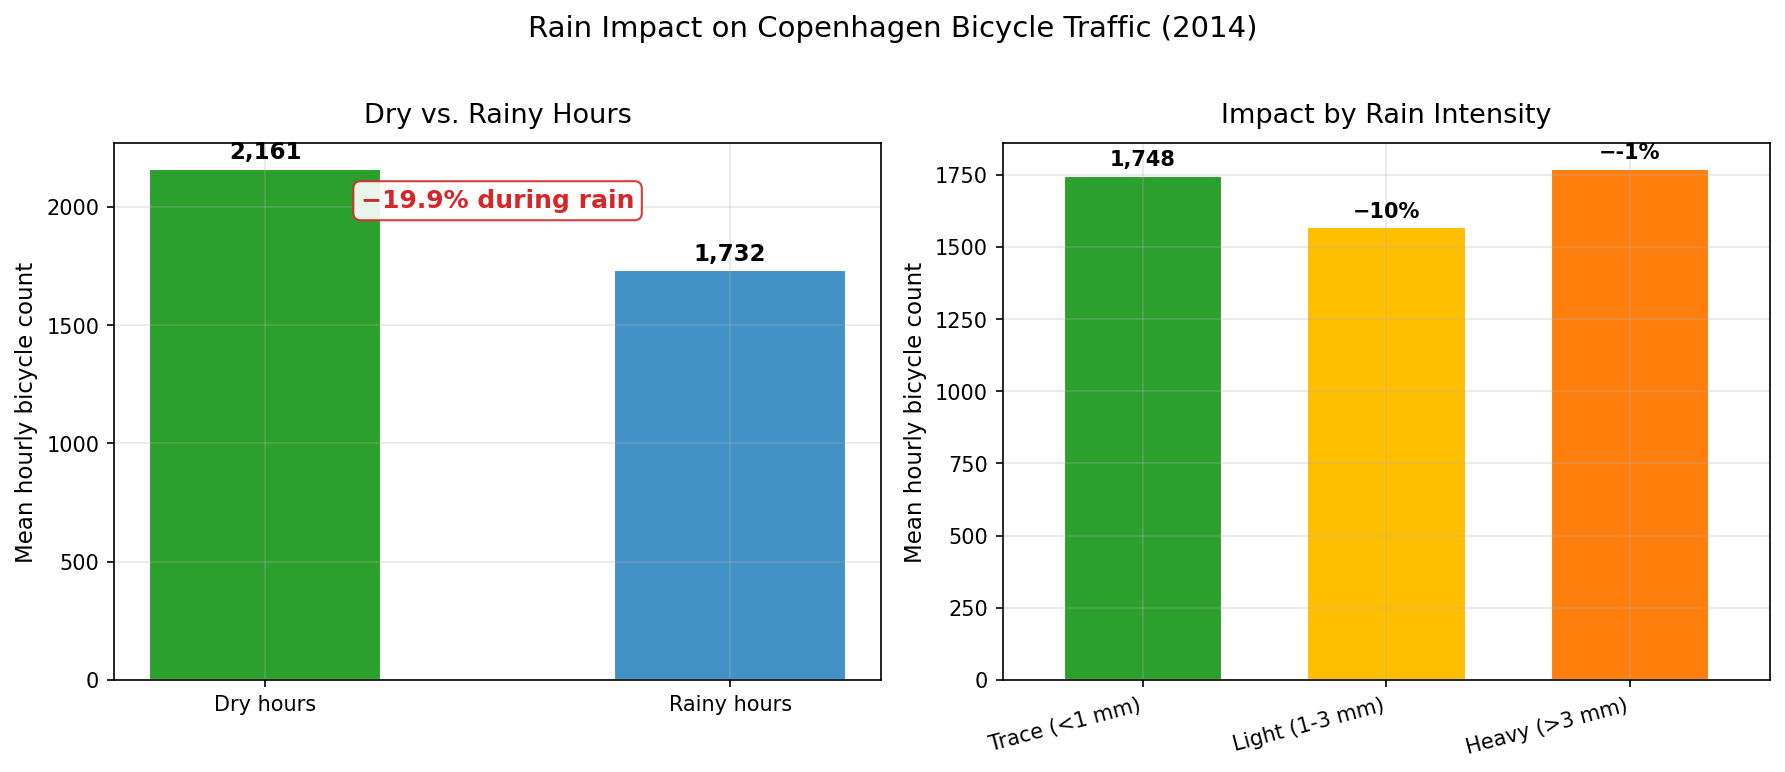

In [15]:
#  Rain Impact: dry vs. rainy + intensity breakdown
rain_bins   = [0, 0.001, 1, 3, 100]
rain_labels = ["Dry (0 mm)", "Trace (<1 mm)", "Light (1-3 mm)", "Heavy (>3 mm)"]
df_city_hourly["rain_bucket"] = pd.cut(
    df_city_hourly["precip_past1h"], bins=rain_bins, labels=rain_labels, right=True
)
rain_stats = df_city_hourly.groupby("rain_bucket", observed=True)["total_count"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: Dry vs Rainy simple comparison
labels_lr = ["Dry hours", "Rainy hours"]
values_lr = [mean_dry, mean_rain]
colors_lr = ["#2ca02c", "#4292c6"]
bars = axes[0].bar(labels_lr, values_lr, color=colors_lr, edgecolor="white", width=0.5)
axes[0].set_ylabel("Mean hourly bicycle count", fontsize=11)
axes[0].set_title("Dry vs. Rainy Hours", fontsize=13, pad=10)
for bar, val in zip(bars, values_lr):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + mean_dry * 0.02,
                 f"{val:,.0f}", ha="center", fontsize=11, fontweight="bold")
axes[0].annotate(
    f"−{rain_impact_pct:.1f}% during rain",
    xy=(0.5, 0.88), xycoords="axes fraction",
    ha="center", fontsize=12, color="#d62728", fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d62728", alpha=0.9),
)

# Right panel: Mean bikes by rain intensity
bar_colors = ["#2ca02c", "#ffbf00", "#ff7f0e", "#d62728"]
rain_stats.plot.bar(ax=axes[1], color=bar_colors, edgecolor="white", width=0.65)
axes[1].set_ylabel("Mean hourly bicycle count", fontsize=11)
axes[1].set_xlabel("")
axes[1].set_title("Impact by Rain Intensity", fontsize=13, pad=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha="right")

baseline_rain = rain_stats.iloc[0]
for i, (bucket, val) in enumerate(rain_stats.items()):
    drop = (1 - val / baseline_rain) * 100
    label = f"{val:,.0f}" if drop == 0 else f"−{drop:.0f}%"
    axes[1].text(i, val + baseline_rain * 0.02, label,
                 ha="center", fontsize=10, fontweight="bold")

fig.suptitle("Rain Impact on Copenhagen Bicycle Traffic (2014)", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("./docs/images/rain_impact.png", dpi=300, bbox_inches="tight")
print("Saved -> docs/images/rain_impact.png")
plt.show()


---
## Step 3 — Interactive Narrative Visualizations

### 3.1 Fair-Weather Factor per sensor

In [16]:
# Fair-Weather Factor % (how sensitive each bicycle location is to rain)
# Percentage drop in average daily bicycle traffic on rainy days vs. dry days, per sensor location
# Rainy day  = any day where max hourly precip > 1.0 mm
# Dry day = all hourly precip == 0
dry_days = df_sensor_daily.loc[df_sensor_daily["precip_daily"] == 0]
rainy_days = df_sensor_daily.loc[df_sensor_daily["precip_max_h"] > 1.0]

mean_dry_sensor = dry_days.groupby("Vej_Id")["daily_count"].mean()
mean_rain_sensor = rainy_days.groupby("Vej_Id")["daily_count"].mean()

fwf = pd.DataFrame({
    "mean_dry":  mean_dry_sensor,
    "mean_rain": mean_rain_sensor,
})
fwf["fair_weather_factor"] = ((1 - fwf["mean_rain"] / fwf["mean_dry"]) * 100).round(1)

# Merge with sensor metadata
sensor_summary = (
    sensor_coords[["Vej_Id", "Vejnavn", "lat", "lon"]]
    .merge(fwf, left_on="Vej_Id", right_index=True, how="left")
)
sensor_summary["avg_daily"] = (
    df_sensor_daily.groupby("Vej_Id")["daily_count"].mean()
    .reindex(sensor_summary["Vej_Id"]).values
)

print("Fair-Weather Factor per sensor:")
sensor_summary.sort_values("fair_weather_factor", ascending=False)

Fair-Weather Factor per sensor:


,Vej_Id,Vejnavn,lat,lon,mean_dry,mean_rain,fair_weather_factor,avg_daily
0,101 1011492-0 1/ 1 T,Ellebjergvej,55.650522,12.510872,2306.898734,1272.861538,44.8,1646.180602
1015,101 1012890-0 6/ 560 T,Hareskovvej,55.720197,12.494825,3618.116883,2341.296296,35.3,3018.945525
1272,101 1013520-0 0/ 562 T,Kalvebod Brygge,55.667689,12.570876,2476.622222,1686.689655,31.9,1990.682759
1429,101 1017592-0 0/ 635 T,Torvegade,55.670247,12.595038,25624.129412,18666.456790,27.2,22526.854749
1787,101 1018308-0 1/ 516 T,Vigerslev Allé,55.661665,12.518010,3630.835294,2754.222222,24.1,3288.645251
2145,101 1018636-0 0/ 180 T,Åboulevard,55.683375,12.555882,12890.094118,9947.481481,22.8,11692.402235
657,101 1011964-0 0/ 200 T,Frederikssundsvej,55.701761,12.533558,7993.294118,6800.271605,14.9,7955.835196
299,101 1011908-0 0/ 66 T,Fredensbro,55.692289,12.568790,0.705882,97.074074,-13652.2,41.002793
1417,101 1015968-0 1/ 60 T,Roskildevej,55.672726,12.478559,NaN,0.000000,NaN,0.000000


### 3.2 Folium — Interactive "Fair-Weather" Map

A *reader-driven* map: the user hovers over each bicycle counter to see how weather-resilient that route is.  
**Marker size** = average daily traffic.  
**Marker colour** = Fair-Weather Factor (green → resilient, red → rain-sensitive).

In [17]:
# Build Folium map
CPH_CENTER = [55.676, 12.568]

m = folium.Map(
    location=CPH_CENTER,
    zoom_start=12,
    tiles="CartoDB positron",
)

# Colour scale: green (resilient, low FWF) → red (sensitive, high FWF)
fwf_min = sensor_summary["fair_weather_factor"].min()
fwf_max = sensor_summary["fair_weather_factor"].max()
colormap = LinearColormap(
    colors=["#2ca02c", "#ffbf00", "#d62728"],
    vmin=fwf_min, vmax=fwf_max,
    caption="Fair-Weather Factor (% drop in rain)",
)
colormap.add_to(m)

# Scale marker radius: map avg_daily → [6, 25] pixel radius
avg_min = sensor_summary["avg_daily"].min()
avg_max = sensor_summary["avg_daily"].max()

def scale_radius(val, lo=avg_min, hi=avg_max, r_min=8, r_max=28):
    if hi == lo:
        return (r_min + r_max) / 2
    return r_min + (val - lo) / (hi - lo) * (r_max - r_min)

for _, row in sensor_summary.iterrows():
    tooltip_html = (
        f"<b>{row['Vejnavn']}</b><br>"
        f"Avg daily traffic: <b>{row['avg_daily']:,.0f}</b> bikes<br>"
        f"Fair-Weather Factor: <b>{row['fair_weather_factor']:.1f}%</b> drop in rain<br>"
        f"<i>Dry-day avg: {row['mean_dry']:,.0f} &nbsp;|&nbsp; Rainy-day avg: {row['mean_rain']:,.0f}</i>"
    )
    if _ == sensor_summary.index[0]:
        valid_fwf = sensor_summary.loc[
            sensor_summary["fair_weather_factor"].between(0, 100),
            "fair_weather_factor",
        ].dropna()

        if not valid_fwf.empty:
            fwf_min = float(valid_fwf.min())
            fwf_max = float(valid_fwf.max())
            colormap.vmin = fwf_min
            colormap.vmax = fwf_max
            colormap.index = [fwf_min, (fwf_min + fwf_max) / 2, fwf_max]

    if (
        pd.isna(row["lat"]) or pd.isna(row["lon"]) or
        pd.isna(row["avg_daily"]) or row["avg_daily"] <= 0 or
        pd.isna(row["fair_weather_factor"]) or
        not (0 <= float(row["fair_weather_factor"]) <= 100)
    ):
        continue

    marker_color = colormap(float(row["fair_weather_factor"]))

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=scale_radius(row["avg_daily"]),
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.75,
        weight=1,
        tooltip=folium.Tooltip(tooltip_html),
    ).add_to(m)

m.save("./docs/visualizations/bike_fairweather_map.html")
print("Saved → docs/visualizations/bike_fairweather_map.html")
m

Saved → docs/visualizations/bike_fairweather_map.html


### 3.3 Plotly — Dual-Axis "City Pulse" Chart

A reader-driven interactive chart that shows the *pulse* of Copenhagen cycling.  
**Left Y-axis** = daily bicycle volume.  **Right Y-axis** = daily precipitation.  
Rainy days are shaded in the background so the impact is immediately visible.

In [18]:
# Plotly dual-axis figure
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Background shading for rainy days
rainy_dates = df_city_daily.loc[df_city_daily["precip_daily"] > 0, "date"]
for d in rainy_dates:
    fig.add_vrect(
        x0=d, x1=d + pd.Timedelta(days=1),
        fillcolor="rgba(100, 149, 237, 0.12)",
        line_width=0,
        layer="below",
    )

# Precipitation bars (right axis)
fig.add_trace(
    go.Bar(
        x=df_city_daily["date"],
        y=df_city_daily["precip_daily"],
        name="Precipitation (mm)",
        marker_color="rgba(100, 149, 237, 0.45)",
        hovertemplate="%{x|%b %d}: %{y:.1f} mm<extra></extra>",
    ),
    secondary_y=True,
)

# Bicycle volume line (left axis)
fig.add_trace(
    go.Scatter(
        x=df_city_daily["date"],
        y=df_city_daily["rolling_7d"],
        name="Bicycle volume (7-day avg)",
        mode="lines",
        line=dict(color="#2171b5", width=2.5),
        hovertemplate="%{x|%b %d}: %{y:,.0f} bikes<extra></extra>",
    ),
    secondary_y=False,
)

# Layout
fig.update_layout(
    title=dict(
        text=(f"Copenhagen's Cycling Pulse: Every Rainy Day Costs the City Riders "
              f"({rain_impact_pct:.0f}% hourly drop)"),
        font_size=15,
    ),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", y=-0.15),
    height=500,
    margin=dict(t=60, b=80),
)

fig.update_yaxes(title_text="Daily bicycle volume (7-day avg)", secondary_y=False,
                 rangemode="tozero")
fig.update_yaxes(title_text="Precipitation (mm)", secondary_y=True,
                 rangemode="tozero", autorange="reversed")
fig.update_xaxes(title_text="", dtick="M1", tickformat="%b")

fig.write_html("./docs/visualizations/bike_weather_pulse.html")
print("Saved -> docs/visualizations/bike_weather_pulse.html")
fig.show()

Saved -> docs/visualizations/bike_weather_pulse.html


#### 3.3b Plotly — Dual-Axis "City Pulse" Chart — Raw Daily

In [19]:
fig_daily = make_subplots(specs=[[{"secondary_y": True}]])

# Background shading for rainy days 
for d in rainy_dates:
    fig_daily.add_vrect(
        x0=d, x1=d + pd.Timedelta(days=1),
        fillcolor="rgba(100, 149, 237, 0.12)",
        line_width=0,
        layer="below",
    )

# Precipitation bars (right axis)
fig_daily.add_trace(
    go.Bar(
        x=df_city_daily["date"],
        y=df_city_daily["precip_daily"],
        name="Precipitation (mm)",
        marker_color="rgba(100, 149, 237, 0.45)",
        hovertemplate="%{x|%b %d}: %{y:.1f} mm<extra></extra>",
    ),
    secondary_y=True,
)

# Raw daily bicycle volume line (left axis)
fig_daily.add_trace(
    go.Scatter(
        x=df_city_daily["date"],
        y=df_city_daily["total_count"],
        name="Bicycle volume (daily)",
        mode="lines",
        line=dict(color="#2171b5", width=1.2),
        opacity=0.8,
        hovertemplate="%{x|%b %d}: %{y:,.0f} bikes<extra></extra>",
    ),
    secondary_y=False,
)

# Layout
fig_daily.update_layout(
    title=dict(
        text=(f"Copenhagen's Cycling Pulse — Raw Daily Count ({rain_impact_pct:.0f}% drop during rain)"),
        font_size=15,
    ),
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", y=-0.15),
    height=500,
    margin=dict(t=60, b=80),
)

fig_daily.update_yaxes(title_text="Daily bicycle volume (raw)", secondary_y=False,
                       rangemode="tozero")
fig_daily.update_yaxes(title_text="Precipitation (mm)", secondary_y=True,
                       rangemode="tozero", autorange="reversed")
fig_daily.update_xaxes(title_text="", dtick="M1", tickformat="%b")

fig_daily.write_html("./docs/visualizations/bike_weather_pulse_daily.html")
print("Saved -> docs/visualizations/bike_weather_pulse_daily.html")
fig_daily.show()

Saved -> docs/visualizations/bike_weather_pulse_daily.html


# The Pulse of Copenhagen: Weather, Bicycles, and Infrastructure
* **The Dataset:** [Copenhagen Open Data](https://portal.opendata.dk) (specifically the bicycle counter data across the city) cross-referenced with weather data from the Danish Meteorological Institute (DMI).
* **The Story / Investigation:** *"Fair-weather Cyclists vs. The Die-Hards."* You can investigate how weather (rain, snow, wind, temperature) alters the flow of the city. Do certain neighborhoods stop biking when it rains while others power through? How do traffic patterns shift during peak winter?
* **The Narrative Flow:** * **Beginning:** A high-level, interactive map of Copenhagen showing the busiest cycling arteries.
  * **Middle (Deep Dive):** Time-series analysis showing the sudden drops in cycling volume. Introduce the weather data.
  * **The ML Component:** Build a predictive model to forecast the number of cyclists at Dronning Louises Bro tomorrow based on the upcoming weather forecast. 
  * **End:** An interactive tool where the user can input "their" commuting route and see how weather impacts their specific path.

## Tips for Narration (The Segel & Heer Requirement)
When you build your website, remember to actively choose a narrative genre. A **"Martini Glass"** structure works incredibly well for this course: 
1. Start with an **author-driven narrative** (scroll-driven text and static charts explaining your basic EDA and machine learning findings).
2. End with a **reader-driven interactive section** (a large interactive map, network graph, or dashboard) where the user can freely play with the data you just explained.